In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

base_url = "data/"
infected_dataset_url = base_url + "time_series_covid19_confirmed_global.csv"
recovered_dataset_url = base_url + "time_series_covid19_recovered_global.csv"
deaths_dataset_url = base_url + "time_series_covid19_deaths_global.csv"

In [2]:
def prepare_time_series(filepath):
    df = pd.read_csv(filepath)
    df = df.drop(["Province/State", "Lat", "Long"], axis=1)
    df = df.groupby("Country/Region").sum()
    df = df.loc[:, df.columns.str.match(r"\d{1,2}/\d{1,2}/\d{2}")]
    df = df.T
    df.index = pd.to_datetime(df.index, format="%m/%d/%y")
    return df

confirmed_df = prepare_time_series(infected_dataset_url)
recovered_df = prepare_time_series(recovered_dataset_url)
deaths_df    = prepare_time_series(deaths_dataset_url)

In [3]:
total_confirmed = confirmed_df.iloc[-1].sort_values(ascending=False).head(10)
total_recovered = recovered_df.iloc[-1].sort_values(ascending=False).head(10)

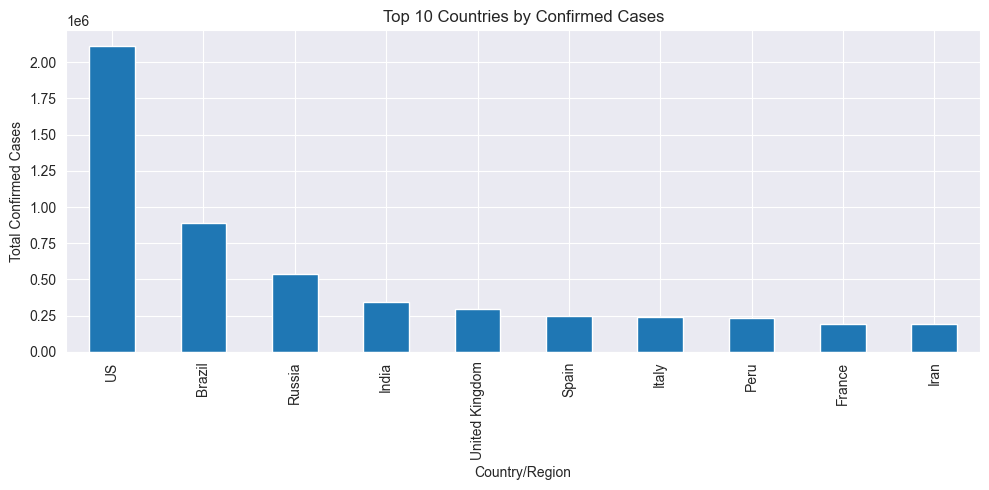

In [4]:
total_confirmed.plot(kind="bar", title="Top 10 Countries by Confirmed Cases", figsize=(10,5))
plt.ylabel("Total Confirmed Cases")
plt.tight_layout()
plt.show()

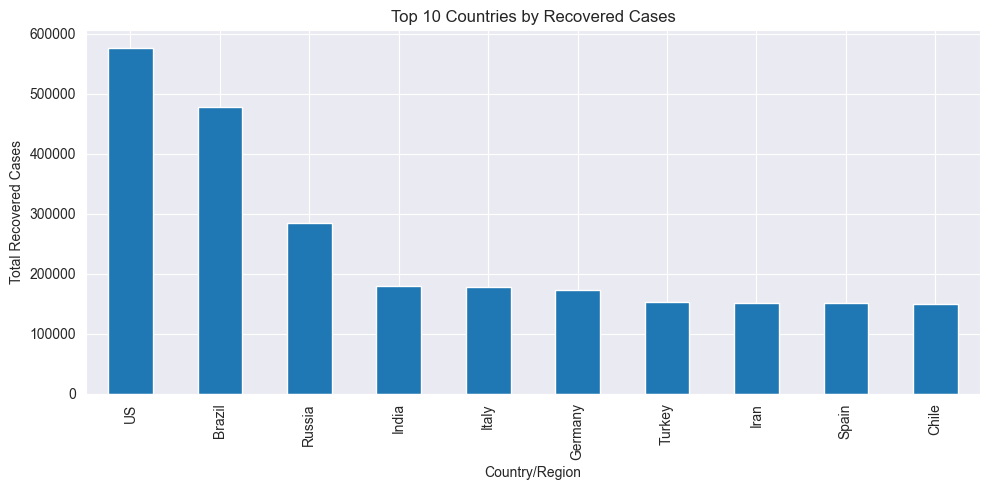

In [5]:
total_recovered.plot(kind="bar", title="Top 10 Countries by Recovered Cases", figsize=(10,5))
plt.ylabel("Total Recovered Cases")
plt.tight_layout()
plt.show()

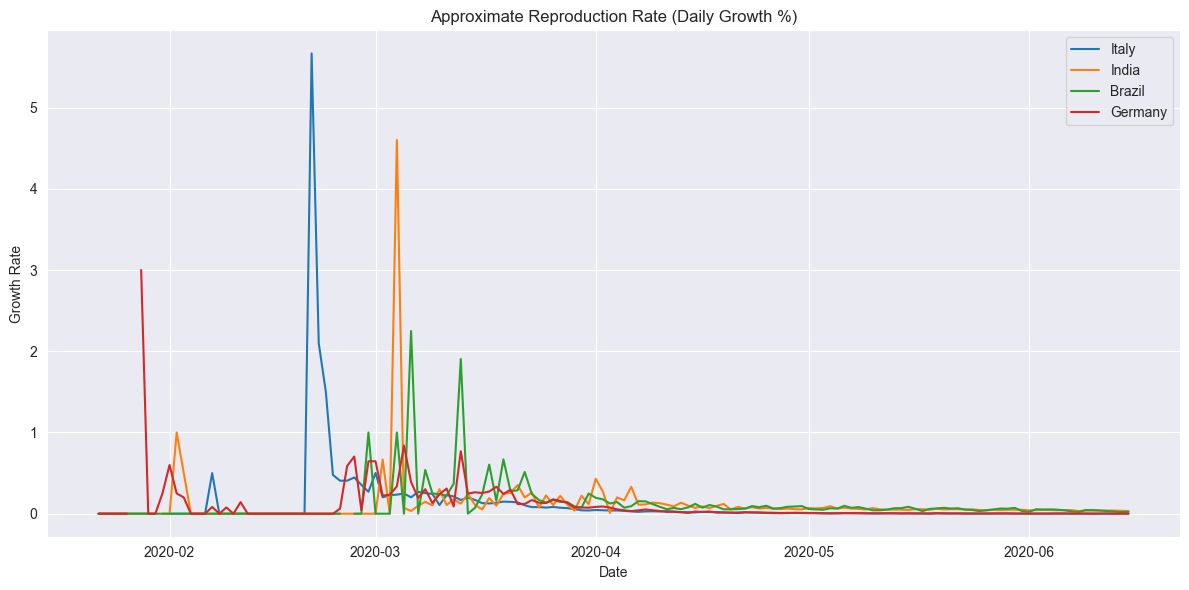

In [6]:
def plot_reproduction_rate(df, countries):
    plt.figure(figsize=(12, 6))
    for country in countries:
        growth = df[country].pct_change().fillna(0)
        plt.plot(growth, label=country)
    plt.title("Approximate Reproduction Rate (Daily Growth %)")
    plt.xlabel("Date")
    plt.ylabel("Growth Rate")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_reproduction_rate(confirmed_df, ["Italy", "India", "Brazil", "Germany"])

Correlation between deaths and recoveries:
             Deaths  Recovered
Deaths     1.000000   0.815125
Recovered  0.815125   1.000000


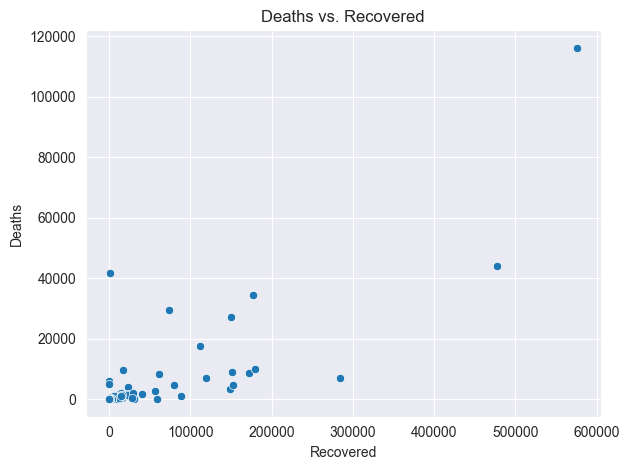

In [7]:
total_deaths = deaths_df.iloc[-1]
total_recovered_all = recovered_df.iloc[-1]

correlation_df = pd.DataFrame({
    "Deaths": total_deaths,
    "Recovered": total_recovered_all
}).dropna()

print("Correlation between deaths and recoveries:")
print(correlation_df.corr())

sns.scatterplot(data=correlation_df, x="Recovered", y="Deaths")
plt.title("Deaths vs. Recovered")
plt.tight_layout()
plt.show()

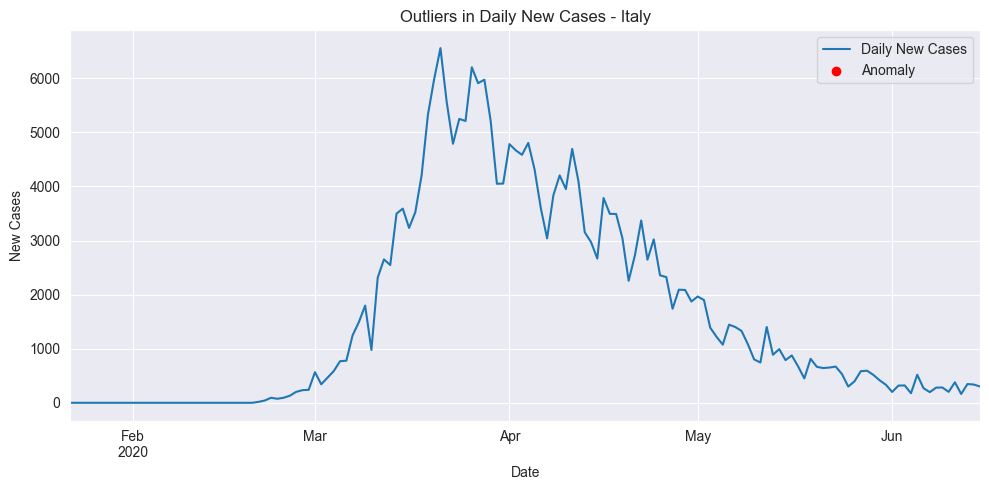

Outlier days in Italy:
Series([], Name: Italy, dtype: float64)


In [8]:
def detect_outliers(df, country):
    daily = df[country].diff().fillna(0)
    Q1 = daily.quantile(0.25)
    Q3 = daily.quantile(0.75)
    IQR = Q3 - Q1
    outliers = daily[(daily < Q1 - 1.5 * IQR) | (daily > Q3 + 1.5 * IQR)]

    plt.figure(figsize=(10, 5))
    daily.plot(label="Daily New Cases")
    plt.scatter(outliers.index.to_numpy(), outliers.values, color='red', label="Anomaly")
    plt.title(f"Outliers in Daily New Cases - {country}")
    plt.xlabel("Date")
    plt.ylabel("New Cases")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return outliers

outliers_italy = detect_outliers(confirmed_df, "Italy")
print("Outlier days in Italy:")
print(outliers_italy)